# Code to visualise tiles partitions 
(this is later defined in SIZE.h and parameters of blanck tiles are defined in data.exch2)

In [1]:
import numpy as np
import xarray as xr
import glob
import os
import matplotlib as mpl
import cmocean

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
PATH_bathy = 'input_binaries/'
PATH_OUTPUT = '/Users/eart0531/Documents/MITgcm_grid/'
filename = 'bathymetry_merged_v1_modified_1440x1440_corrected_45x45_tiles.bin'

In [3]:
nx = 1440 # factors are 2 2 2 2 2 3 3 5
ny = 1440 # factors are 2 2 2 2 2 3 3 5

x = np.arange(0,nx)
y = np.arange(0,ny)

In [4]:
np.gcd(nx,ny) # the largest possible size of tile

1440

In [5]:
tile_size_x, tile_size_y = 45, 45

In [6]:
bathy_tmp = np.fromfile(PATH_bathy + filename, dtype='>f') # >f correponds to big endian binary file (that is used by MITgcm)
bathy_tmp = bathy_tmp.reshape(ny, nx) 


bathy = np.where(bathy_tmp==0., np.NaN, bathy_tmp)
del bathy_tmp

bathy = xr.DataArray(np.array(bathy, dtype=float),
                       dims=['y', 'x'],
                       coords={'x' : x, 'y' : y})

In [7]:
fig = plt.figure(figsize=(15,12)) 

mpl.rcParams.update({'font.size': 18}) # increase default font size in matplotlib
mpl.rcParams.update({'xtick.labelsize': 15})
mpl.rcParams.update({'ytick.labelsize': 15})

bathy.plot.contourf(levels=15,cmap='cmo.deep') 

num_tiles_x = int(nx/tile_size_x) 
num_tiles_y = int(ny/tile_size_y)

if nx%tile_size_x !=0:
    print("Error in tile size in X dimension: number of tiles is not a factor of grid!")
#     stop
if ny%tile_size_y !=0:
    print("Error in tile size in X dimension: number of tiles is not a factor of grid!")
#     stop
    
for ii in range(0, num_tiles_y):
    plt.axhline(tile_size_x*ii, c='r', linewidth=1)
    
for ii in range(0, num_tiles_x):
    plt.axvline(tile_size_x*ii, c='r', linewidth=1)
    
icount = 1

for jj in range(num_tiles_y):
    for ii in range(num_tiles_x):
        plt.text(tile_size_x*(ii+1)-tile_size_x/2, (jj+1)*tile_size_y-tile_size_y/2, str(icount), va = 'center', ha = 'center', fontsize=9)
        icount = icount+1
    
plt.savefig(PATH_OUTPUT+'tile_partition_lookup_'+'_1440x1440_' + str(tile_size_x)+'x'+str(tile_size_y)+ '.pdf') 

NameError: name 'bathy' is not defined

<Figure size 1080x864 with 0 Axes>

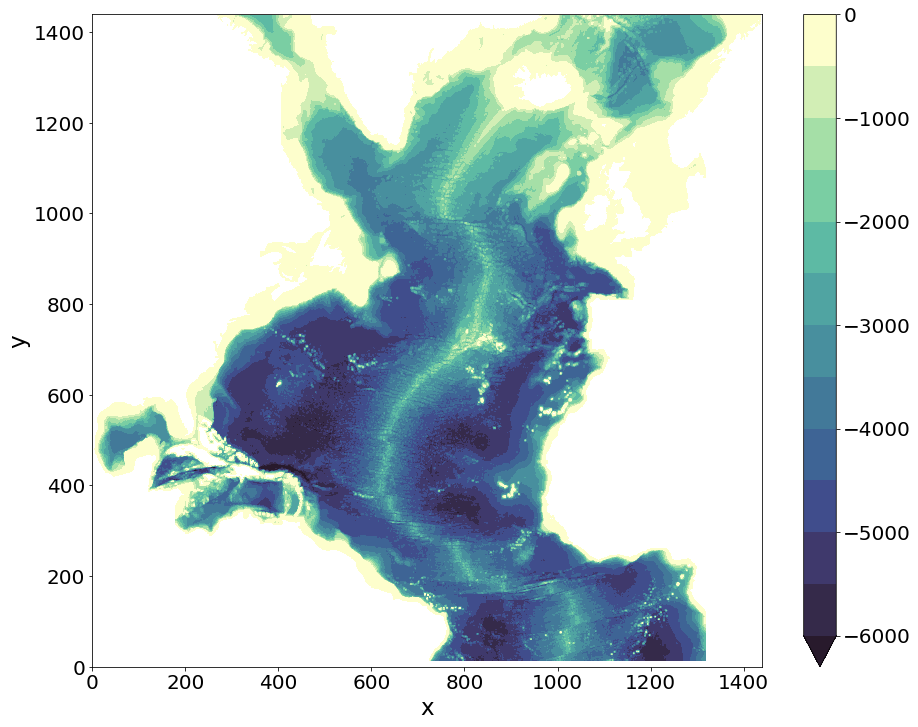

In [29]:
fig = plt.figure(figsize=(15,12)) 

mpl.rcParams.update({'font.size': 23}) # increase default font size in matplotlib
mpl.rcParams.update({'xtick.labelsize': 20})
mpl.rcParams.update({'ytick.labelsize': 20})

bathy.plot.contourf(vmin=-6000, vmax=0, levels=13, cmap='cmo.deep_r') 

# colormap.set_bad(color='k', alpha=None)

num_tiles_x = int(nx/tile_size_x) 
num_tiles_y = int(ny/tile_size_y)

# if nx%tile_size_x !=0:
#     print("Error in tile size in X dimension: number of tiles is not a factor of grid!")
#     stop
# if ny%tile_size_y !=0:
#     print("Error in tile size in X dimension: number of tiles is not a factor of grid!")
#     stop
    
# for ii in range(0, num_tiles_y):
#     plt.axhline(tile_size_x*ii, c='r', linewidth=1)
    
# for ii in range(0, num_tiles_x):
#     plt.axvline(tile_size_x*ii, c='r', linewidth=1)
    
# icount = 1

# for jj in range(num_tiles_y):
#     for ii in range(num_tiles_x):
#         plt.text(tile_size_x*(ii+1)-tile_size_x/2, (jj+1)*tile_size_y-tile_size_y/2, str(icount), va = 'center', ha = 'center', fontsize=18)
#         icount = icount+1
    
# plt.savefig(PATH_OUTPUT+'MITgcm_1440x1440_grid_no_tiles.pdf') 